# Data augmentation with ASL dataset

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will use data augmentation techniques to improve the performance of our model on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [63]:
import random

import torch.nn as nn
import pandas as pd
import torch
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

In [65]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/" if IN_COLAB else "./data/asl_data/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [66]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [67]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

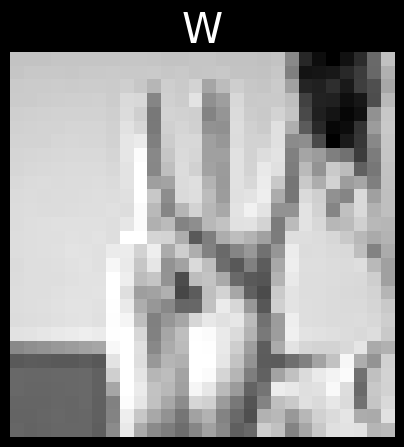

In [68]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [69]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [70]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [71]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [72]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [73]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [74]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

To avoid repeating code, we can define a custom class for each convolutional block (conv layer, activation, and pooling) and then use it to build our CNN model.

In [75]:
class ConvolutionalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout_p):
        super().__init__()
        kernel_size = 3

        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=1, padding=1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.MaxPool2d(2, stride=2)
        )

    def forward(self, x):
        return self.model(x)

In [76]:
model_cnn = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [77]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [02:18<00:00,  6.91s/epoch, train_acc=0.9966, train_loss=0.0115, val_acc=0.9598, val_loss=0.2581]


In [78]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

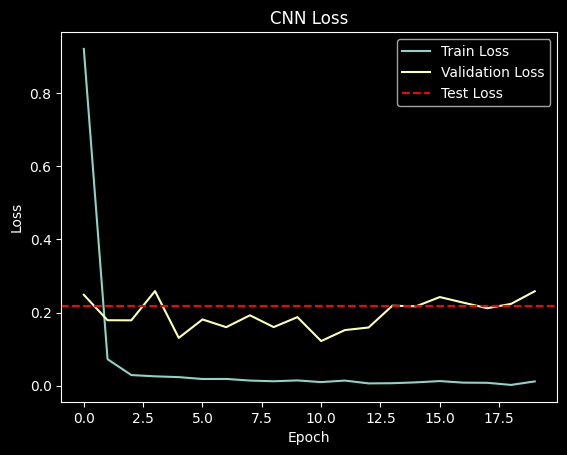

In [79]:
plt.plot(cnn_res['train_loss'], label='Train Loss')
plt.plot(cnn_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_test_loss, label='Test Loss', linestyle='--', color='r')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Data Augmentation

Data augmentation is a technique used to artificially increase the size of a training dataset by creating modified versions of the existing data. This can help improve the generalization of a model and reduce overfitting, especially when the original dataset is small.

The increase in size gives the model more images to learn from while training. The increase in variance helps the model ignore unimportant features and select only the features that are truly important in classification, allowing it to generalize better.

### Random resized crop

This transform will randomly resize the input image based on `scale`, and then crop it to a size we specify. In this case, we will crop it to the original image dimensions. To do this, TorchVision needs to know the aspect ratio of the image it is scaling. Since our height is the same as our width, our aspect `ratio` is 1:1.

In [80]:
trans = transforms.Compose([
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.7, 1), ratio=(1, 1)),
])

In [81]:
def compare_images(_img, t):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(F.to_pil_image(_img), cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    img_transformed = t(_img).cpu()
    axes[1].imshow(F.to_pil_image(img_transformed), cmap='gray')
    axes[1].set_title("Transformed Image")
    axes[1].axis('off')
    plt.show()

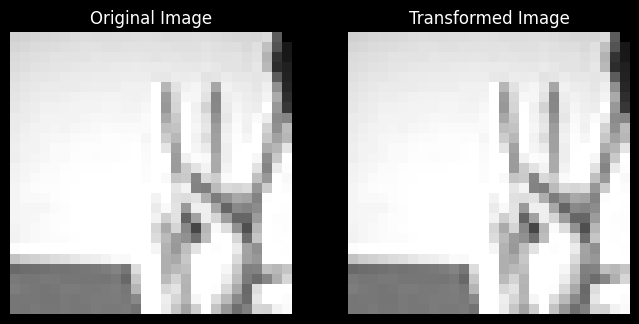

In [82]:
random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Random horizontal flip

We can also randomly flip our images [Horizontally](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomHorizontalFlip) or [Vertically](https://pytorch.org/vision/0.9/transforms.html#torchvision.transforms.RandomVerticalFlip). However, for these images, we will only flip them horizontally.

American Sign Language can be done with either the left or right hand being dominant. However, it is unlikely to see sign language from upside down. This kind of domain-specific reasoning can help make good decisions for your own deep learning applications.

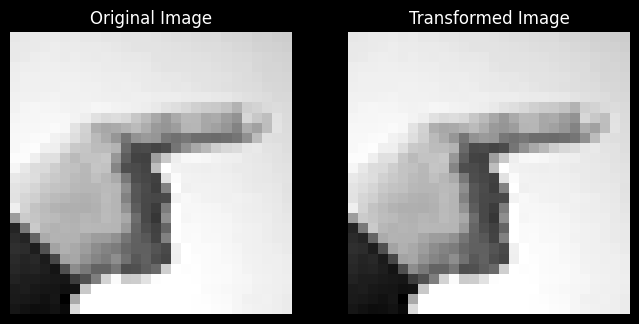

In [83]:
trans = transforms.Compose([
    transforms.RandomHorizontalFlip()
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Random rotation

We can also randomly rotate the image to add more variability. Just like with with other augmentation techniques, it's easy to accidentally go too far. With ASL, if we rotate too much, our `D`s might look like `G`s and visa versa. Because of this, let's limit it to `30` degrees.

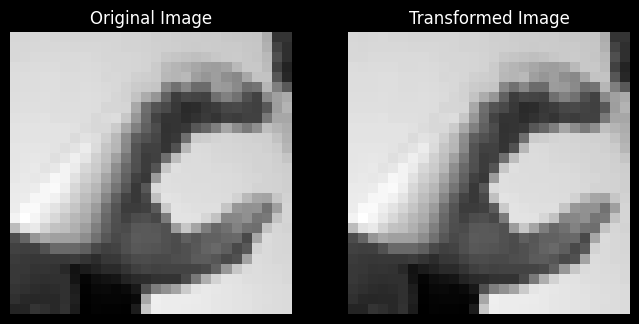

In [84]:
trans = transforms.Compose([
    transforms.RandomRotation(30)
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

### Color jitter

The `ColorJitter` transform has 4 arguments:, brightness, contrast, saturation and hue


The latter 2 apply to color images, so we will only use the first 2 for now.

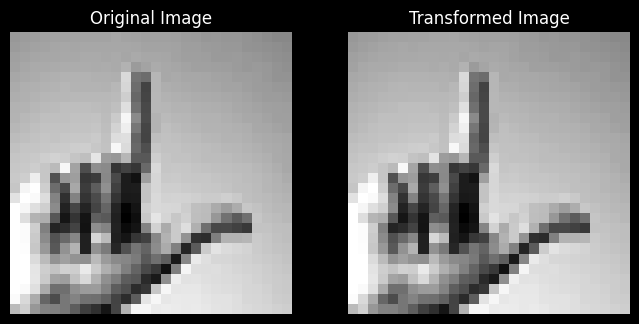

In [85]:
brightness = .2  # Change to be from 0 to 1
contrast = .5  # Change to be from 0 to 1

trans = transforms.Compose([
    transforms.ColorJitter(brightness=brightness, contrast=contrast)
])

random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), trans)

## Training with augmentation

Data augmentation occurs during the training loop, where the defined transformations are applied to the training images. We will create a new training function that includes an extra argument with the transformations, and applies them to each batch of training data before feeding it into the model.

In [86]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            _x = X_batch
            if _transforms is not None:
                _x = _transforms(_x)
            outputs = _model(_x)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

Let's also define our transformations in a single variable so we can easily pass it to our training function.

In [87]:
random_transforms = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.9, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.5)
])

We can also visualize the transformations to see how they are changing the images.

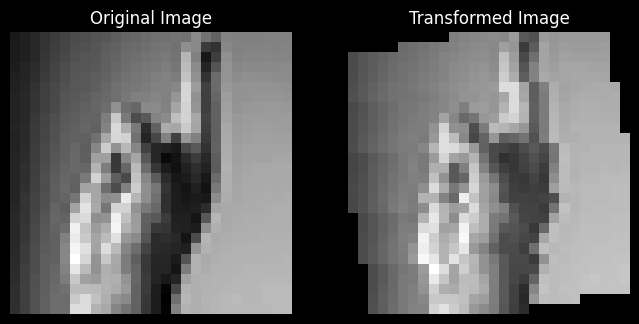

In [88]:
random_idx = random.randint(0, len(train_data) - 1)
img, _ = train_data[random_idx]
compare_images(img.cpu(), random_transforms)

Now we can train the CNN model again, but this time with the defined augmentations applied to the training data.

Note that the augmentation only applies during training, so the test method remains unchanged. Also, this transformation pipeline is inherent to the training loop, so it should not be included in the Dataset or the model itself, as it is only relevant during training.

In [89]:
model_cnn_aug = nn.Sequential(
    ConvolutionalBlock(IMG_CHANNELS, 25, 0), # 25 x 14 x 14
    ConvolutionalBlock(25, 50, 0.2),  # 50 x 7 x 7
    ConvolutionalBlock(50, 75, 0),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),

    nn.Linear(512, 24)
)

model_cnn_aug = model_cnn_aug.to(device)

In [60]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn_aug.parameters())

cnn_aug_res = train(model_cnn_aug, train_loader, val_loader, loss_function, optimizer, epochs, random_transforms)

Training: 100%|██████████| 20/20 [02:27<00:00,  7.38s/epoch, train_acc=0.9820, train_loss=0.0593, val_acc=0.9732, val_loss=0.0969]


In [61]:
cnn_aug_test_loss, cnn_aug_test_acc = test(model_cnn_aug, test_loader, loss_function)

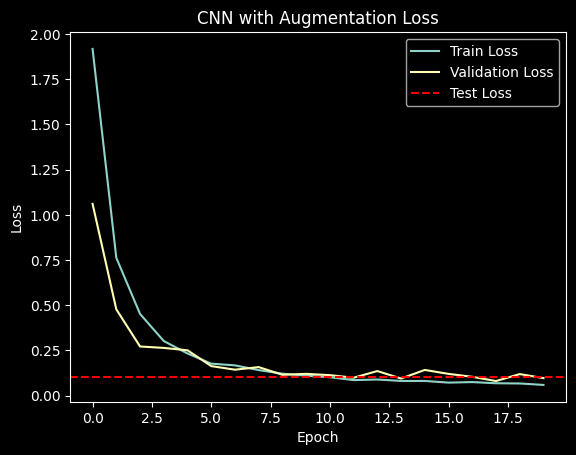

In [62]:
plt.plot(cnn_aug_res['train_loss'], label='Train Loss')
plt.plot(cnn_aug_res['val_loss'], label='Validation Loss')
plt.axhline(cnn_aug_test_loss, label='Test Loss', linestyle='--', color='r')
plt.legend()
plt.title('CNN with Augmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Reflection section

En esta primera parte aprendí que el data augmentation no solo sirve para cambiar imágenes, sino para ayudar al modelo a aprender de una forma más variada. Al comparar los resultados, entendí mejor que estas transformaciones pueden hacer que la red no se quede solo con patrones muy específicos del entrenamiento, sino que tenga una mejor capacidad para reconocer datos nuevos. También aprendí que no cualquier cambio en la imagen es útil, sino que debe tener sentido con el problema que se quiere resolver.

In [90]:
def entrenar(modelo, cargador_train, cargador_val, criterio, optimizador, num_epocas, transformaciones=None):
    historial = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    iterador = tqdm(range(num_epocas), desc="Entrenando", unit="epoca")

    for _ in iterador:
        modelo.train()
        perdida_train = 0.0
        acc_train = 0.0

        for x_batch, y_batch in cargador_train:
            optimizador.zero_grad()
            x_entrada = transformaciones(x_batch) if transformaciones is not None else x_batch
            salida = modelo(x_entrada)
            perdida = criterio(salida, y_batch)
            perdida.backward()
            optimizador.step()

            perdida_train += perdida.item() * x_batch.size(0)
            acc_train += get_batch_accuracy(salida, y_batch, len(cargador_train.dataset))

        perdida_train = perdida_train / len(cargador_train.dataset)

        modelo.eval()
        perdida_val = 0.0
        acc_val = 0.0

        with torch.no_grad():
            for x_val, y_val in cargador_val:
                salida_val = modelo(x_val)
                perdida_val += criterio(salida_val, y_val).item() * x_val.size(0)
                acc_val += get_batch_accuracy(salida_val, y_val, len(cargador_val.dataset))

        perdida_val = perdida_val / len(cargador_val.dataset)

        iterador.set_postfix(
            train_loss=f"{perdida_train:.4f}",
            train_acc=f"{acc_train:.4f}",
            val_loss=f"{perdida_val:.4f}",
            val_acc=f"{acc_val:.4f}",
        )

        historial['train_loss'].append(perdida_train)
        historial['train_acc'].append(acc_train)
        historial['val_loss'].append(perdida_val)
        historial['val_acc'].append(acc_val)

    return historial


def probar(modelo, cargador_test, criterio):
    modelo.eval()
    perdida_test = 0.0
    acc_test = 0.0

    with torch.no_grad():
        for x, y in cargador_test:
            salida = modelo(x)
            perdida_test += criterio(salida, y).item() * x.size(0)
            acc_test += get_batch_accuracy(salida, y, len(cargador_test.dataset))

    return perdida_test / len(cargador_test.dataset), acc_test


def crear_modelo_cnn():
    modelo = nn.Sequential(
        ConvolutionalBlock(IMG_CHANNELS, 25, 0),
        ConvolutionalBlock(25, 50, 0.2),
        ConvolutionalBlock(50, 75, 0),
        nn.Flatten(),
        nn.Linear(75 * 3 * 3, 512),
        nn.Dropout(.3),
        nn.ReLU(),
        nn.Linear(512, 24)
    )
    return modelo.to(device)


def resumir_resultados(historial, test_loss, test_acc):
    return {
        'mejor_train_acc': max(historial['train_acc']),
        'mejor_val_acc': max(historial['val_acc']),
        'mejor_val_loss': min(historial['val_loss']),
        'test_loss': test_loss,
        'test_acc': test_acc
    }

### What impact did data augmentation had on the model performance?

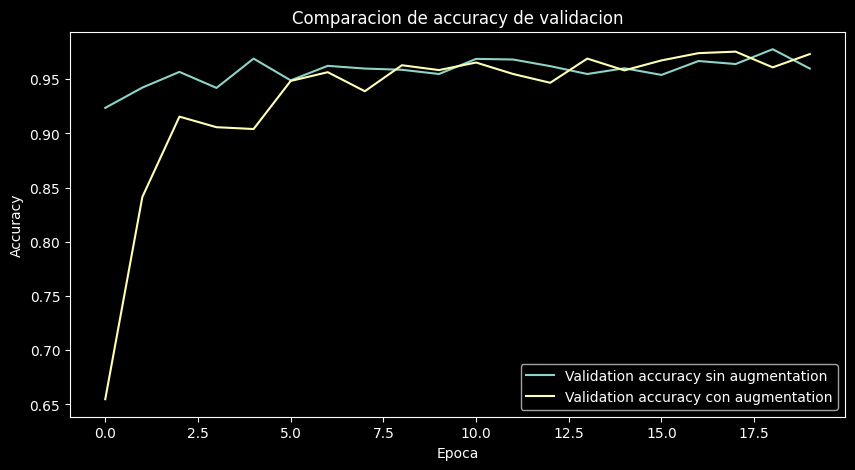

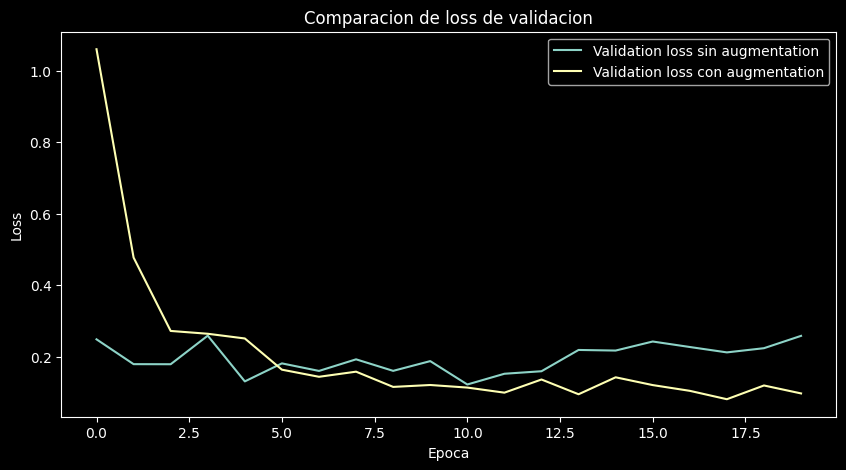

El data augmentation mejoro el rendimiento del modelo en el conjunto de prueba. La exactitud en test paso de 96.07% sin augmentation a 97.27% con augmentation, lo que representa un cambio de +1.20 puntos porcentuales. La perdida en test paso de 0.2168 a 0.1029, por lo que disminuyo la capacidad de generalizacion. Ademas, la mejor exactitud de validacion fue de 97.77% sin augmentation y de 97.55% con augmentation. La diferencia entre train y validation disminuyo, ya que paso de 2.17 a 0.65 puntos porcentuales, lo cual ayuda a evaluar si hubo menos o mas sobreajuste.


In [91]:
resumen_base = resumir_resultados(cnn_res, cnn_test_loss, cnn_test_acc)
resumen_aug = resumir_resultados(cnn_aug_res, cnn_aug_test_loss, cnn_aug_test_acc)

plt.figure(figsize=(10, 5))
plt.plot(cnn_res['val_acc'], label='Validation accuracy sin augmentation')
plt.plot(cnn_aug_res['val_acc'], label='Validation accuracy con augmentation')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.title('Comparacion de accuracy de validacion')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cnn_res['val_loss'], label='Validation loss sin augmentation')
plt.plot(cnn_aug_res['val_loss'], label='Validation loss con augmentation')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Comparacion de loss de validacion')
plt.legend()
plt.show()

delta_test_acc = (resumen_aug['test_acc'] - resumen_base['test_acc']) * 100
delta_test_loss = resumen_aug['test_loss'] - resumen_base['test_loss']
brecha_base = resumen_base['mejor_train_acc'] - resumen_base['mejor_val_acc']
brecha_aug = resumen_aug['mejor_train_acc'] - resumen_aug['mejor_val_acc']

cambio_acc = "mejoro" if delta_test_acc > 0 else "empeoro" if delta_test_acc < 0 else "se mantuvo igual"
cambio_loss = "disminuyo" if delta_test_loss < 0 else "aumento" if delta_test_loss > 0 else "se mantuvo igual"
cambio_brecha = "disminuyo" if brecha_aug < brecha_base else "aumento" if brecha_aug > brecha_base else "se mantuvo igual"

texto_impacto = (
    f"El data augmentation {cambio_acc} el rendimiento del modelo en el conjunto de prueba. "
    f"La exactitud en test paso de {resumen_base['test_acc']*100:.2f}% sin augmentation a "
    f"{resumen_aug['test_acc']*100:.2f}% con augmentation, lo que representa un cambio de "
    f"{delta_test_acc:+.2f} puntos porcentuales. La perdida en test paso de "
    f"{resumen_base['test_loss']:.4f} a {resumen_aug['test_loss']:.4f}, por lo que {cambio_loss} "
    f"la capacidad de generalizacion. Ademas, la mejor exactitud de validacion fue de "
    f"{resumen_base['mejor_val_acc']*100:.2f}% sin augmentation y de "
    f"{resumen_aug['mejor_val_acc']*100:.2f}% con augmentation. La diferencia entre train y validation "
    f"{cambio_brecha}, ya que paso de {brecha_base*100:.2f} a {brecha_aug*100:.2f} puntos porcentuales, "
    f"lo cual ayuda a evaluar si hubo menos o mas sobreajuste."
)

print(texto_impacto)

### Re-run training with a smaller subset of train data (both with augmentation and without it)

Entrenando: 100%|██████████| 20/20 [00:31<00:00,  1.55s/epoca, train_acc=0.9284, train_loss=0.2103, val_acc=0.9322, val_loss=0.1936]


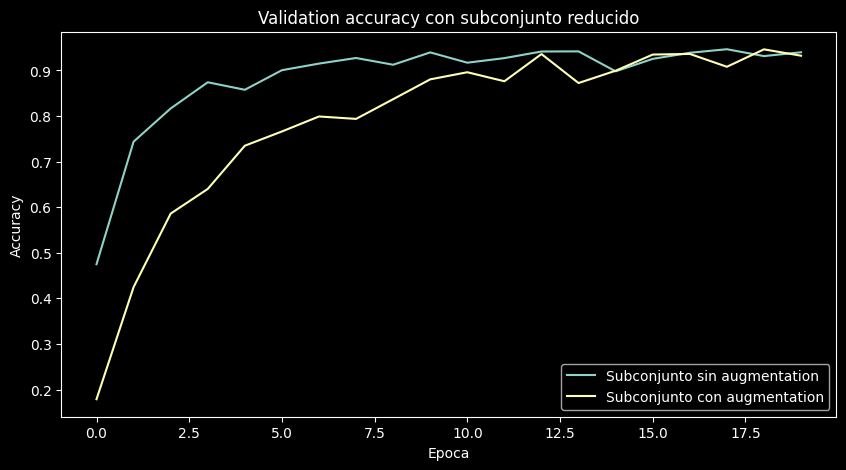

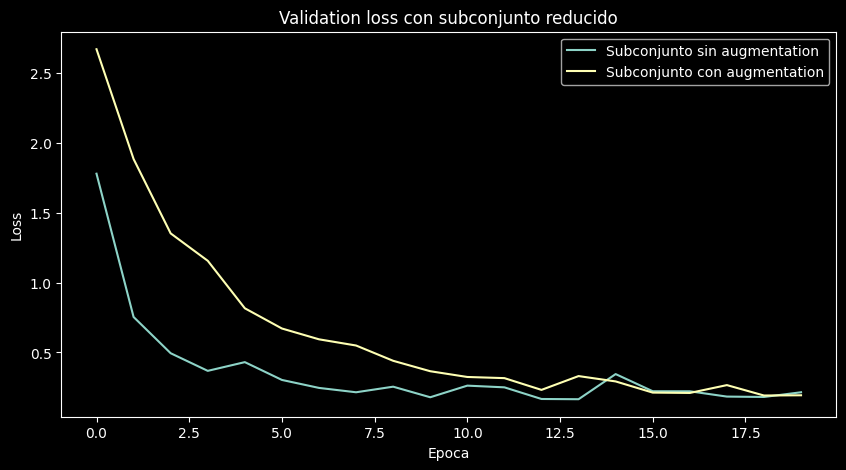

Al reducir el conjunto de entrenamiento al 20% del total, el modelo sin augmentation obtuvo una exactitud de 93.98% en test, mientras que el modelo con augmentation obtuvo 92.94%. La diferencia entre ambos fue de -1.03 puntos porcentuales a favor del modelo sin augmentation. Comparado con el entrenamiento usando todo el conjunto, la exactitud del modelo base cayo 2.09 puntos porcentuales y la del modelo con augmentation cayo 4.32 puntos porcentuales. Esto permite observar si el augmentation ayuda mas cuando hay menos datos disponibles.


In [92]:
fraccion_subconjunto = 0.20
epocas_subconjunto = 20

train_df_pequeno = train_df.sample(frac=fraccion_subconjunto, random_state=42).reset_index(drop=True)
train_data_pequeno = AslDataset(train_df_pequeno)
train_loader_pequeno = DataLoader(train_data_pequeno, batch_size=batch_size, shuffle=True)

modelo_pequeno_base = crear_modelo_cnn()
optimizador_pequeno_base = Adam(modelo_pequeno_base.parameters())
historial_pequeno_base = entrenar(
    modelo_pequeno_base,
    train_loader_pequeno,
    val_loader,
    loss_function,
    optimizador_pequeno_base,
    epocas_subconjunto
)
test_loss_pequeno_base, test_acc_pequeno_base = probar(modelo_pequeno_base, test_loader, loss_function)

modelo_pequeno_aug = crear_modelo_cnn()
optimizador_pequeno_aug = Adam(modelo_pequeno_aug.parameters())
historial_pequeno_aug = entrenar(
    modelo_pequeno_aug,
    train_loader_pequeno,
    val_loader,
    loss_function,
    optimizador_pequeno_aug,
    epocas_subconjunto,
    random_transforms
)
test_loss_pequeno_aug, test_acc_pequeno_aug = probar(modelo_pequeno_aug, test_loader, loss_function)

plt.figure(figsize=(10, 5))
plt.plot(historial_pequeno_base['val_acc'], label='Subconjunto sin augmentation')
plt.plot(historial_pequeno_aug['val_acc'], label='Subconjunto con augmentation')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.title('Validation accuracy con subconjunto reducido')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(historial_pequeno_base['val_loss'], label='Subconjunto sin augmentation')
plt.plot(historial_pequeno_aug['val_loss'], label='Subconjunto con augmentation')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Validation loss con subconjunto reducido')
plt.legend()
plt.show()

delta_subconjunto = (test_acc_pequeno_aug - test_acc_pequeno_base) * 100
caida_base = (cnn_test_acc - test_acc_pequeno_base) * 100
caida_aug = (cnn_aug_test_acc - test_acc_pequeno_aug) * 100

texto_subconjunto = (
    f"Al reducir el conjunto de entrenamiento al {fraccion_subconjunto*100:.0f}% del total, "
    f"el modelo sin augmentation obtuvo una exactitud de {test_acc_pequeno_base*100:.2f}% en test, "
    f"mientras que el modelo con augmentation obtuvo {test_acc_pequeno_aug*100:.2f}%. "
    f"La diferencia entre ambos fue de {delta_subconjunto:+.2f} puntos porcentuales a favor del modelo "
    f"{'con augmentation' if delta_subconjunto > 0 else 'sin augmentation' if delta_subconjunto < 0 else 'sin diferencia clara'}. "
    f"Comparado con el entrenamiento usando todo el conjunto, la exactitud del modelo base cayo "
    f"{caida_base:.2f} puntos porcentuales y la del modelo con augmentation cayo {caida_aug:.2f} puntos porcentuales. "
    f"Esto permite observar si el augmentation ayuda mas cuando hay menos datos disponibles."
)

print(texto_subconjunto)

### Re-train the model using a different transformation pipeline for augmentation

Refer to the following documentation page: https://docs.pytorch.org/vision/stable/transforms.html

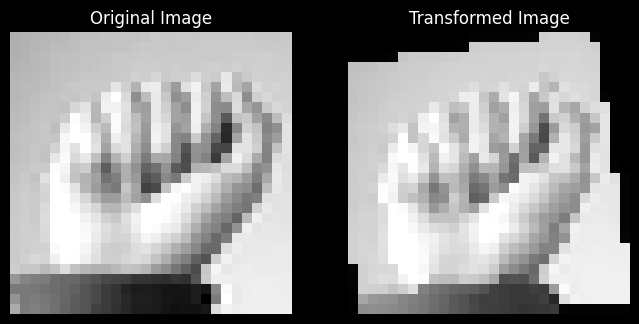

Entrenando: 100%|██████████| 20/20 [02:20<00:00,  7.04s/epoca, train_acc=0.9638, train_loss=0.1101, val_acc=0.9841, val_loss=0.0419]


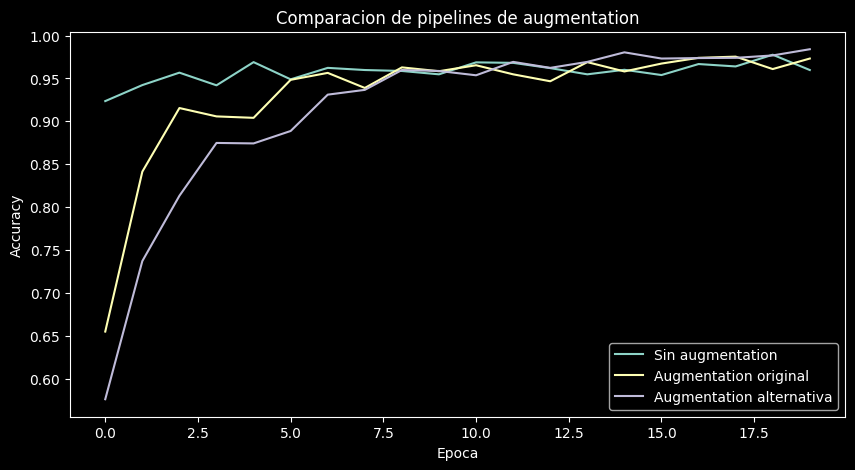

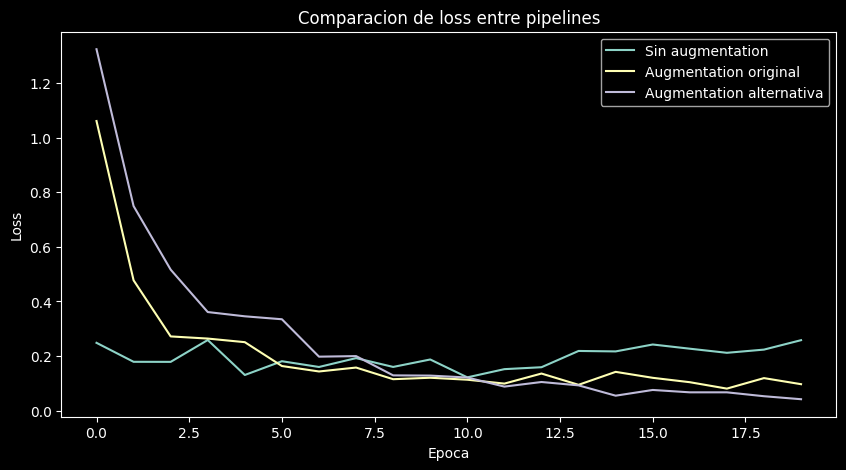

La tuberia alternativa de augmentation obtuvo una exactitud de 98.41% en test y una perdida de 0.0387. Frente al modelo sin augmentation, la diferencia fue de +2.34 puntos porcentuales. Frente a la tuberia original de augmentation, la diferencia fue de +1.14 puntos porcentuales. Con esto se puede determinar si una estrategia basada en transformaciones afines, volteo horizontal y desenfoque gaussiano resulta mas conveniente que la tuberia original.


In [93]:
transformaciones_alternativas = transforms.Compose([
    transforms.RandomAffine(degrees=12, translate=(0.08, 0.08), scale=(0.95, 1.05), shear=5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
])

indice_aleatorio = random.randint(0, len(train_data) - 1)
imagen_ejemplo, _ = train_data[indice_aleatorio]
compare_images(imagen_ejemplo.cpu(), transformaciones_alternativas)

epocas_alternativas = 20
modelo_aug_alternativo = crear_modelo_cnn()
optimizador_aug_alternativo = Adam(modelo_aug_alternativo.parameters())

historial_aug_alternativo = entrenar(
    modelo_aug_alternativo,
    train_loader,
    val_loader,
    loss_function,
    optimizador_aug_alternativo,
    epocas_alternativas,
    transformaciones_alternativas
)

test_loss_aug_alternativo, test_acc_aug_alternativo = probar(
    modelo_aug_alternativo,
    test_loader,
    loss_function
)

plt.figure(figsize=(10, 5))
plt.plot(cnn_res['val_acc'], label='Sin augmentation')
plt.plot(cnn_aug_res['val_acc'], label='Augmentation original')
plt.plot(historial_aug_alternativo['val_acc'], label='Augmentation alternativa')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.title('Comparacion de pipelines de augmentation')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(cnn_res['val_loss'], label='Sin augmentation')
plt.plot(cnn_aug_res['val_loss'], label='Augmentation original')
plt.plot(historial_aug_alternativo['val_loss'], label='Augmentation alternativa')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Comparacion de loss entre pipelines')
plt.legend()
plt.show()

delta_alt_vs_base = (test_acc_aug_alternativo - cnn_test_acc) * 100
delta_alt_vs_original = (test_acc_aug_alternativo - cnn_aug_test_acc) * 100

texto_pipeline = (
    f"La tuberia alternativa de augmentation obtuvo una exactitud de {test_acc_aug_alternativo*100:.2f}% en test "
    f"y una perdida de {test_loss_aug_alternativo:.4f}. Frente al modelo sin augmentation, la diferencia fue de "
    f"{delta_alt_vs_base:+.2f} puntos porcentuales. Frente a la tuberia original de augmentation, la diferencia fue de "
    f"{delta_alt_vs_original:+.2f} puntos porcentuales. Con esto se puede determinar si una estrategia basada en "
    f"transformaciones afines, volteo horizontal y desenfoque gaussiano resulta mas conveniente que la tuberia original."
)

print(texto_pipeline)

### Write down your final remarks

In [94]:
resultados_finales = [
    ("CNN sin augmentation", cnn_test_acc, cnn_test_loss),
    ("CNN con augmentation original", cnn_aug_test_acc, cnn_aug_test_loss),
    ("CNN con augmentation alternativo", test_acc_aug_alternativo, test_loss_aug_alternativo),
    ("Subconjunto sin augmentation", test_acc_pequeno_base, test_loss_pequeno_base),
    ("Subconjunto con augmentation", test_acc_pequeno_aug, test_loss_pequeno_aug),
]

mejor_modelo = max(resultados_finales, key=lambda x: x[1])
mejora_full = (cnn_aug_test_acc - cnn_test_acc) * 100
mejora_sub = (test_acc_pequeno_aug - test_acc_pequeno_base) * 100

if mejora_full > 0 and mejora_sub > 0:
    conclusion_augmentation = "En ambos escenarios, el data augmentation ayudo a mejorar la generalizacion del modelo."
elif mejora_full > 0 and mejora_sub <= 0:
    conclusion_augmentation = "El data augmentation fue util con el conjunto completo, pero no mostro la misma ventaja al trabajar con un subconjunto reducido."
elif mejora_full <= 0 and mejora_sub > 0:
    conclusion_augmentation = "El data augmentation no mejoro claramente el experimento con todos los datos, pero si resulto util cuando el entrenamiento se hizo con menos ejemplos."
else:
    conclusion_augmentation = "En estos experimentos, el data augmentation no produjo una mejora consistente, lo que sugiere que la eleccion de transformaciones debe ajustarse mejor al problema."

texto_final = (
    f"En esta practica se compararon distintos entrenamientos de una CNN para clasificar letras del lenguaje de senas americano. "
    f"El mejor resultado en test fue obtenido por {mejor_modelo[0]}, con una exactitud de {mejor_modelo[1]*100:.2f}% y una perdida de {mejor_modelo[2]:.4f}. "
    f"{conclusion_augmentation} "
    f"Ademas, al reducir el tamano del conjunto de entrenamiento se observo con mayor claridad el efecto de tener menos datos disponibles, "
    f"lo que permite evaluar mejor la utilidad del augmentation como tecnica de apoyo. En general, este experimento muestra que el rendimiento del modelo "
    f"no depende solo de la arquitectura, sino tambien de la cantidad de datos y del tipo de transformaciones aplicadas durante el entrenamiento."
)

print(texto_final)

En esta practica se compararon distintos entrenamientos de una CNN para clasificar letras del lenguaje de senas americano. El mejor resultado en test fue obtenido por CNN con augmentation alternativo, con una exactitud de 98.41% y una perdida de 0.0387. El data augmentation fue util con el conjunto completo, pero no mostro la misma ventaja al trabajar con un subconjunto reducido. Ademas, al reducir el tamano del conjunto de entrenamiento se observo con mayor claridad el efecto de tener menos datos disponibles, lo que permite evaluar mejor la utilidad del augmentation como tecnica de apoyo. En general, este experimento muestra que el rendimiento del modelo no depende solo de la arquitectura, sino tambien de la cantidad de datos y del tipo de transformaciones aplicadas durante el entrenamiento.


Con esta parte aprendí que el rendimiento de un modelo no depende solamente de la arquitectura que se use, sino también de cuántos datos tiene y de cómo se preparan esos datos. Al probar distintos pipelines de augmentation y además reducir el conjunto de entrenamiento, pude entender mejor cómo cambia la generalización del modelo en cada caso. En general, me quedó más claro que el data augmentation puede ser una herramienta muy útil, pero su impacto depende del tipo de transformaciones que se apliquen y de qué tan bien se adapten al contexto del problema.